In [1]:
import numpy as np
import re
import subprocess
import matplotlib.pyplot as plt
import matplotlib 
import astropy.units as u
from astropy.io import fits
from astropy.constants import m_p, M_sun, L_sun
import multiprocessing as mp
import itertools

import os
gd_folder = os.getcwd()+"/../../Calculations/SKIRTOR/"

import sys 
sys.path.append(gd_folder)
#from loadSKIRTOR_MRN77 import LoadSKIRTOR_MRN77
from loadSKIRTOR_MRN77_force_reg import LoadSKIRTOR_MRN77
from loadSKIRTOR_General import LoadSKIRTOR_General

sys.path.append("../utility_functions/")
from objectProperties import ObjectProperties
from readExtrapolatedSpectra import ReadExtrapolatedSpectra

sys.path.append("../../Filter_Curves/")
from readBands import ReadBands

In [2]:
#Use the latex font when plotting. 
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.family'] = 'STIXGeneral'

In [3]:
#Load the properties of the BHDs
op = ObjectProperties()

In [4]:
#Load the bands.
bands = ReadBands()
for bname in bands.bandnames:
    print(bname, bands.bp[bname].barlam(), bands.bp[bname].fwhm(), bands.bp[bname].rectwidth())

R_SPECIAL 6501.229535920617 Angstrom 1159.881393925198 Angstrom 1624.9974574790472 Angstrom
I_BESS 7925.773360798338 Angstrom 1080.5202412457434 Angstrom 1433.1539789444323 Angstrom
v_HIGH 5531.691038305597 Angstrom 850.6231300284223 Angstrom 1195.0838113345558 Angstrom


In [5]:
#Load the spectra for each BHD, extended using the best-fit SED.
specs = ReadExtrapolatedSpectra()

Wavelength range for object W0019-1046 limited because of sky template
Spec-range: 3001.5 Angstrom - 5423.93 Angstrom
Sky-range: 3199.4 Angstrom - 6724.06 Angstrom
Wavelength range for object W0204-0506 limited because of sky template
Spec-range: 3786.2 Angstrom - 6672.70 Angstrom
Sky-range: 3789.3 Angstrom - 6682.76 Angstrom
Warning, 2 of 3161 bins contained negative fluxes; they have been set to zero.
Wavelength range for object W0831+0140 limited because of sky template
Spec-range: 3786.2 Angstrom - 6672.45 Angstrom
Sky-range: 3789.3 Angstrom - 6682.76 Angstrom
Warning, 2 of 3161 bins contained negative fluxes; they have been set to zero.


In [6]:
#Read the chi2 maps for each model. To compute the chi^2 map, run the fit_pfrac.ipynb notebook. 
p_map = dict()
chi2_map = dict()
for wid in op.wids:
    fname = "maps/chi2_map_{}.fits".format(wid)
    if os.path.exists(fname):
        h = fits.open(fname)
        tang_grid = np.array(h[0].header['TANGGRID'].split()).astype(float)
        tang_grid = tang_grid * u.Unit(h[0].header['TANGUNIT'])
        cang_grid = np.array(h[0].header['CANGGRID'].split()).astype(float)
        cang_grid = cang_grid * u.Unit(h[0].header['CANGUNIT'])
        iang_grid = np.array(h[0].header['IANGGRID'].split()).astype(float)
        iang_grid = iang_grid * u.Unit(h[0].header['IANGUNIT'])
        chi2_map[wid] = np.ma.zeros((len(tang_grid), len(cang_grid), len(iang_grid)))
        chi2_map[wid][:,:,:] = h[0].data
        chi2_map[wid].mask = h[1].data.astype(bool)
        print(wid, chi2_map[wid][0,0,0])
    else:
        print("Model files not found. Please run the fit_pfrac notebook first.")

W0019-1046 64.60903701329913
W0204-0506 1402.8429752066115
W0220+0137 1226.7955292570675
W0831+0140 346.890625
W0116-0505 4306.388520634797


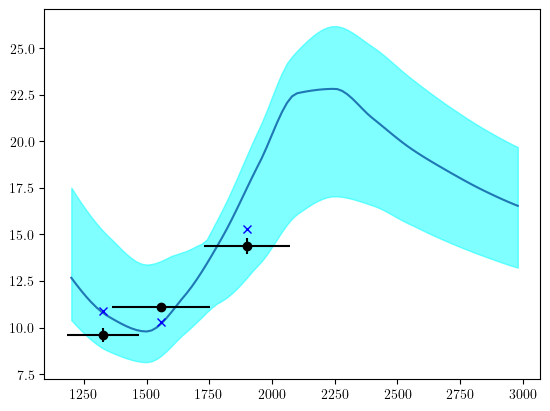

In [18]:
#Make the plot for W0116-0505. This is not a paper plot, but just a test for now. 
wid = "W0116-0505"

#This is the grid in which we want to interpolate using the pchip method.
lam_grid = np.arange(1200., 3000., 20.)*u.AA

pw_l = LoadSKIRTOR_MRN77(cone_type='Full', interp_method='linear')
pw_p = LoadSKIRTOR_MRN77(cone_type='Full', interp_method='pchip')

#Plot the range of models. 
#indices = np.argwhere(chi2_map[wid]<=np.min(chi2_map[wid])+1.0)
indices = np.argwhere(chi2_map[wid]<=np.min(2.0*chi2_map[wid]))

n_threads = mp.cpu_count()-1 #15
splt_indices = np.array_split(indices, n_threads)

def func(x):
    results = np.zeros((len(x), len(lam_grid)))
    for rn, ind in enumerate(x):
        i, j, k = ind
        results[rn] = 100*pw_p.p((tang_grid[i]*np.ones(lam_grid.shape), cang_grid[j]*np.ones(lam_grid.shape), iang_grid[k]*np.ones(lam_grid.shape), lam_grid.value))
    return(results)

with mp.Pool(processes=n_threads) as pool:
    all_results = pool.map(func, splt_indices)
result = np.vstack(all_results)
curve_min = np.min(result, axis=0)
curve_max = np.max(result, axis=0)
plt.fill_between(lam_grid.value, curve_min, curve_max, color='cyan', alpha=0.5)

#Now plot the best fit. 
i, j, k = np.unravel_index(np.argmin(chi2_map[wid], axis=None), chi2_map[wid].shape)
plt.plot(lam_grid, 100*pw_p.p((tang_grid[i]*np.ones(lam_grid.shape), cang_grid[j]*np.ones(lam_grid.shape), iang_grid[k]*np.ones(lam_grid.shape), lam_grid)))

for bname in op.pfrac[wid].keys():
    plt.errorbar([bands.bp[bname].barlam().value/(1+op.z[wid])], [op.pfrac[wid][bname]], xerr=[bands.bp[bname].rectwidth().value/2./(1+op.z[wid])], yerr=[op.epfrac[wid][bname]], marker='o', color='k')

    #p_mod = pw_p.p_bb(bands.bp[bname], tang_grid[i:i+1], cang_grid[j:j+1], iang_grid[k:k+1], specs.lam_obs[wid], specs.flam[wid], op.z[wid])
    p_mod = pw_l.p_bb(bands.bp[bname], tang_grid[i:i+1], cang_grid[j:j+1], iang_grid[k:k+1], specs.lam_obs[wid], specs.flam[wid], op.z[wid])
    plt.plot([bands.bp[bname].barlam().value/(1+op.z[wid])], [p_mod[0,0,0]*100], 'bx')

In [8]:
#Obtain the combined chi2 of the fit. Specifically, we optimize the fit for every objects for a fixed combination of torus and cone openings and generate a chi2 map in this way. 
chi2_all = np.zeros(chi2_map[op.wids[0]].shape[:2])
for wid in op.wids:
    chi2_all += np.min(chi2_map[wid], axis=2)

i, j = np.unravel_index(np.argmin(chi2_all, axis=None), chi2_all.shape)
print("Torus opening: {} Cone opening: {} Combined Chi2: {:.2f}".format(tang_grid[i], cang_grid[j], chi2_all.min()))
for wid in op.wids:
    print("{} Inclination: {} Chi2: {:.2f}".format(wid, iang_grid[np.argmin(chi2_map[wid][i,j])], np.min(chi2_map[wid][i,j])))

Torus opening: 42.5 deg Cone opening: 36.5 deg Combined Chi2: 30.13
W0019-1046 Inclination: 51.5 deg Chi2: 0.00
W0204-0506 Inclination: 84.5 deg Chi2: 0.00
W0220+0137 Inclination: 90.0 deg Chi2: 0.08
W0831+0140 Inclination: 62.5 deg Chi2: 0.02
W0116-0505 Inclination: 73.0 deg Chi2: 30.03


In [11]:
#Repeat obtaining the best-fit but now masking the regions not allowed in the model. 
chi2_all_masked = np.zeros(chi2_map[op.wids[0]].shape[:2])
for wid in op.wids:
    for i, tang in enumerate(tang_grid):
        for j, cang in enumerate(cang_grid):
            if tang>cang:
                cond = iang_grid>tang
                chi2_all_masked[i,j] += np.min(chi2_map[wid][i,j,cond])
            else:
                chi2_all_masked[i,j] = np.inf

i, j = np.unravel_index(np.argmin(chi2_all_masked, axis=None), chi2_all.shape)
print(tang_grid[i], cang_grid[j], chi2_all_masked.min())
for wid in op.wids:
    print(wid, iang_grid[np.argmin(chi2_map[wid][i,j])], np.min(chi2_map[wid][i,j]))

42.5 deg 36.5 deg 30.127532231339856
W0019-1046 51.5 deg 0.0013514979773651186
W0204-0506 84.5 deg 7.758922895348541e-06
W0220+0137 90.0 deg 0.07585005384476948
W0831+0140 62.5 deg 0.02185994147034352
W0116-0505 73.0 deg 30.028462979124484


In [9]:
#Set the additional SKIRT models we want to plot for W0116-0505. 
wid = "W0116-0505"
other_sk_models = [
    {"d03_mod":"MW"},
    {"d03_mod":"LMC"},
    {"d03_mod":"SMC"},
    #{"gs_min":0.005, "gs_max":0.25, "a":3.5},
    {"gs_min":1, "gs_max":10, "a":3.5, "sil":True},
    #{"gs_min":0.1, "gs_max":1, "a":0.0},
    #{"gs_min":0.1, "gs_max":1, "a":3.5},
    {"gs_min":0.1, "gs_max":1, "a":3.5, "sil":True},
]


n_mod = len(other_sk_models)
n_band = len(op.pfrac[wid].keys())
n_threads = np.min([mp.cpu_count()-1, n_mod*n_band])
#n_threads = np.min([int(mp.cpu_count()/2), len(other_sk_models)*len(op.pfrac[wid].keys())])
indices = list(itertools.product( np.arange(n_mod) , np.arange(n_band)))
splt_indices = np.array_split(indices, n_threads)

other_sk = list()
for oskm in other_sk_models:
    other_sk.append(LoadSKIRTOR_General(**oskm, interp_method='pchip'))

bnames = list(op.pfrac[wid].keys())
def func(x):
    result = np.zeros((n_mod, n_band, len(iang_grid)))
    for ind in x:
        k, j = ind
        bname = bnames[j]
        p_aux = other_sk[k].p_bb(bands.bp[bname], iang_grid, specs.lam_obs[wid], specs.flam[wid], specs.specs.sp[wid].zspec)
        result[k,j] = ((p_aux*100 - op.pfrac[wid][bname])/op.epfrac[wid][bname])**2
    return result

with mp.Pool(processes=n_threads) as pool:
    all_results = pool.map(func, splt_indices)
other_chi2 = (np.sum(all_results, axis=0)).sum(axis=1)


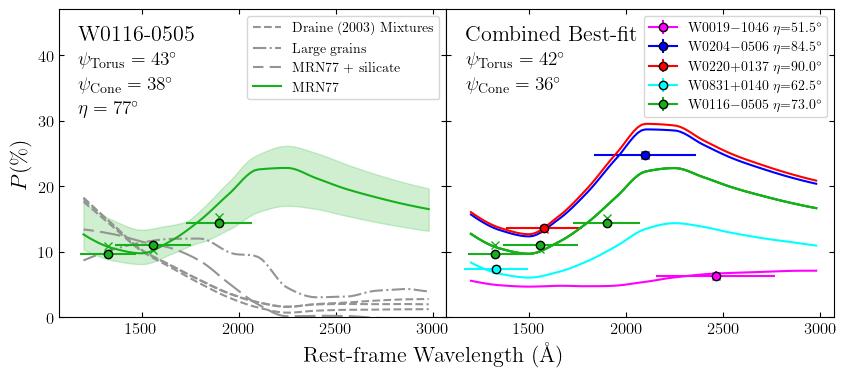

In [21]:
#Plot for the paper.

colors = {"W0116-0505":"xkcd:green", "W0019-1046":"magenta", "W0204-0506":"blue", "W0220+0137":"red", "W0831+0140":"cyan"}

fig, axs = plt.subplots(1,2, figsize=(10,4), sharey=True, sharex=True)
plt.subplots_adjust(wspace=0., hspace=0.)

for ax in axs:
    ax.tick_params(axis="both", direction="in", labelsize=12, bottom=True, top=True, left=True, right=True)

#On one plot, we show the best solution for W0116-0505. 
lam_grid = np.arange(1200., 3000., 20.)*u.AA
wid = "W0116-0505"

#First plot the range of plaussible models. 
#indices = np.argwhere(chi2_map[wid]<=np.min(chi2_map[wid])+1.0)
indices = np.argwhere(chi2_map[wid]<=2.0*np.min(chi2_map[wid]))

n_threads = mp.cpu_count()-1 #15
splt_indices = np.array_split(indices, n_threads)

def func(x):
    results = np.zeros((len(x), len(lam_grid)))
    for rn, ind in enumerate(x):
        i, j, k = ind
        results[rn] = 100*pw_p.p((tang_grid[i]*np.ones(lam_grid.shape), cang_grid[j]*np.ones(lam_grid.shape), iang_grid[k]*np.ones(lam_grid.shape), lam_grid.value))
    return(results)

with mp.Pool(processes=n_threads) as pool:
    all_results = pool.map(func, splt_indices)
result = np.vstack(all_results)
curve_min = np.min(result, axis=0)
curve_max = np.max(result, axis=0)
axs[0].fill_between(lam_grid.value, curve_min, curve_max, color=colors[wid], alpha=0.2)

labels = ['Draine (2003) Mixtures', None, None, 'Large grains', 'MRN77 + silicate']
for mm, osk in enumerate(other_sk):
    kk = np.argmin(other_chi2[mm])
    ls = 'dashed'
    if mm==3:
        ls = 'dashdot'
    elif mm==4:
        ls = (5, (10,3))
    elif mm==5:
        ls = 'dotted'
    axs[0].plot(lam_grid, 100*osk.p((iang_grid[kk]*np.ones(lam_grid.shape), lam_grid)), c='xkcd:grey',ls=ls, label=labels[mm])
i1, j1, k1 = np.unravel_index(np.argmin(chi2_map[wid], axis=None), chi2_map[wid].shape)
axs[0].plot(lam_grid, 100*pw_p.p((tang_grid[i1]*np.ones(lam_grid.shape), cang_grid[j1]*np.ones(lam_grid.shape), iang_grid[k1]*np.ones(lam_grid.shape), lam_grid)), c=colors[wid],ls='solid', label='MRN77')

for bname in op.pfrac[wid].keys():

    axs[0].errorbar([bands.bp[bname].barlam().value/(1+op.z[wid])], [op.pfrac[wid][bname]], xerr=[bands.bp[bname].rectwidth().value/2./(1+op.z[wid])], yerr=[op.epfrac[wid][bname]], marker='o', c=colors[wid], markeredgecolor='black')

    #p_mod = pw_p.p_bb(bands.bp[bname], tang_grid[i1:i1+1], cang_grid[j1:j1+1], iang_grid[k1:k1+1], specs.lam_obs[wid], specs.flam[wid], op.z[wid])
    p_mod = pw_l.p_bb(bands.bp[bname], tang_grid[i1:i1+1], cang_grid[j1:j1+1], iang_grid[k1:k1+1], specs.lam_obs[wid], specs.flam[wid], op.z[wid])
    axs[0].plot([bands.bp[bname].barlam().value/(1+op.z[wid])], [p_mod[0,0,0]*100], c=colors[wid], marker='x')

axs[0].text(0.05, 0.9, "W0116-0505", transform=axs[0].transAxes, fontsize=16, weight='bold')
axs[0].text(0.05, 0.82, r"$\psi_{{\rm Torus}} = {:.0f}^{{\circ}}$".format(tang_grid[i1].value), transform=axs[0].transAxes, fontsize=14)
axs[0].text(0.05, 0.74, r"$\psi_{{\rm Cone}}  = {:.0f}^{{\circ}}$".format(cang_grid[j1].value), transform=axs[0].transAxes, fontsize=14)
axs[0].text(0.05, 0.66, r"$\eta = {:.0f}^{{\circ}}$".format(iang_grid[k1].value), transform=axs[0].transAxes, fontsize=14)

axs[0].legend()#loc=(0.45, 0.55))

#On the other, we will show the combined best fit.  
lam_grid = np.arange(1200., 3000., 20.)*u.AA
for wid in op.wids:
    i2, j2 = np.unravel_index(np.argmin(chi2_all_masked, axis=None), chi2_all.shape)
    for bname in op.pfrac[wid].keys():

        k2 = np.argmin(chi2_map[wid][i2,j2,:])

        if bname == "R_SPECIAL":
            label = r"{} $\eta$=${}^{{\circ}}$".format(re.sub("-","$-$",wid), iang_grid[k2].value)
        else:
            label = None

        axs[1].plot(lam_grid, 100*pw_p.p((tang_grid[i2]*np.ones(lam_grid.shape), cang_grid[j2]*np.ones(lam_grid.shape), iang_grid[k2]*np.ones(lam_grid.shape), lam_grid)), c=colors[wid],ls='solid')

        axs[1].errorbar([bands.bp[bname].barlam().value/(1+op.z[wid])], [op.pfrac[wid][bname]], xerr=[bands.bp[bname].rectwidth().value/2./(1+op.z[wid])], yerr=[op.epfrac[wid][bname]], marker='o', color=colors[wid], markeredgecolor='black', label=label)

        #p_mod = pw_p.p_bb(bands.bp[bname], tang_grid[i2:i2+1], cang_grid[j2:j2+1], iang_grid[k2:k2+1], specs.lam_obs[wid], specs.flam[wid], op.z[wid])
        p_mod = pw_l.p_bb(bands.bp[bname], tang_grid[i2:i2+1], cang_grid[j2:j2+1], iang_grid[k2:k2+1], specs.lam_obs[wid], specs.flam[wid], op.z[wid])
        axs[1].plot([bands.bp[bname].barlam().value/(1+op.z[wid])], [p_mod[0,0,0]*100], c=colors[wid], marker='x')

axs[1].text(0.05, 0.9, "Combined Best-fit", transform=axs[1].transAxes, fontsize=16, weight='bold')
axs[1].text(0.05, 0.82, r"$\psi_{{\rm Torus}} = {:.0f}^{{\circ}}$".format(tang_grid[i2].value), transform=axs[1].transAxes, fontsize=14)
axs[1].text(0.05, 0.74, r"$\psi_{{\rm Cone}}  = {:.0f}^{{\circ}}$".format(cang_grid[j2].value), transform=axs[1].transAxes, fontsize=14)
axs[1].legend(loc='upper right')

axs[0].set_ylim([0., 47.])

axs[0].set_ylabel(r"$P (\%)$", fontsize=16)
fig.text(0.5, 0., r"Rest-frame Wavelength $(\rm \AA)$", ha='center', fontsize=16)

fig.savefig("SKIRTOR_MRN77_best-fit_pchip.png", dpi=100, bbox_inches='tight')


In [14]:
op.__dict__

{'wids': ['W0019-1046',
  'W0204-0506',
  'W0220+0137',
  'W0831+0140',
  'W0116-0505'],
 'filters': {'W0019-1046': ['R_SPECIAL'],
  'W0204-0506': ['R_SPECIAL'],
  'W0220+0137': ['R_SPECIAL'],
  'W0831+0140': ['R_SPECIAL'],
  'W0116-0505': ['R_SPECIAL', 'I_BESS', 'v_HIGH']},
 'script_folder': '/home/rjassef/Impol_Blue_HotDOGs/Impol_BHDs_repo/plots/utility_functions',
 'pfrac': {'W0019-1046': {'R_SPECIAL': 6.35},
  'W0204-0506': {'R_SPECIAL': 24.72},
  'W0220+0137': {'R_SPECIAL': 13.66},
  'W0831+0140': {'R_SPECIAL': 7.45},
  'W0116-0505': {'R_SPECIAL': 11.11, 'I_BESS': 14.36, 'v_HIGH': array(9.62)}},
 'epfrac': {'W0019-1046': {'R_SPECIAL': 0.79},
  'W0204-0506': {'R_SPECIAL': 0.66},
  'W0220+0137': {'R_SPECIAL': 0.39},
  'W0831+0140': {'R_SPECIAL': 0.4},
  'W0116-0505': {'R_SPECIAL': 0.22, 'I_BESS': 0.43, 'v_HIGH': array(0.38)}},
 'z': {'W0019-1046': 1.641,
  'W0116-0505': 3.173,
  'W0204-0506': 2.099307,
  'W0220+0137': 3.122,
  'W0831+0140': 3.888}}